In [1]:
import pandas as pd
import numpy as np
import warnings
from sqlalchemy import create_engine
from urllib.parse import quote_plus
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2
import statistics as stats
from scipy.stats import t
warnings.filterwarnings('ignore')

# Connection details
host = 'localhost'
user = 'postgres'
password = quote_plus('Shiv@11$')  # Encode special characters
dbname = 'Data Science Projects'
port = 5432

# Connect to PostgreSQL
engine = create_engine(f"postgresql://{user}:{password}@{host}:{port}/{dbname}")

In [2]:
df = pd.read_sql('''SELECT * FROM vendor_sales_summary''',engine)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080.0,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038.0,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407.0,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682.0,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109.0,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10692 entries, 0 to 10691
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorNumber           10692 non-null  int64  
 1   VendorName             10692 non-null  object 
 2   Brand                  10692 non-null  int64  
 3   Description            10692 non-null  object 
 4   PurchasePrice          10692 non-null  float64
 5   ActualPrice            10692 non-null  float64
 6   Volume                 10692 non-null  float64
 7   TotalPurchaseQuantity  10692 non-null  float64
 8   TotalPurchaseDollars   10692 non-null  float64
 9   TotalSalesQuantity     10692 non-null  float64
 10  TotalSalesDollars      10692 non-null  float64
 11  TotalSalesPrice        10692 non-null  float64
 12  TotalExciseTax         10692 non-null  float64
 13  FreightCost            10692 non-null  float64
 14  GrossProfit            10692 non-null  float64
 15  Pr

In [4]:
df.describe()

,VendorNumber,Brand,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesPurchaseRatio
count,10692.000000,10692.000000,10692.000000,10692.000000,10692.000000,10692.000000,1.069200e+04,10692.000000,1.069200e+04,10692.000000,10692.000000,10692.000000,1.069200e+04,10692.000000,10692.000000,10692.000000
mean,10650.649458,18039.228769,24.385303,35.643671,847.360550,3140.886831,3.010669e+04,3129.583317,4.295417e+04,19111.958773,1804.263569,61433.763214,1.284748e+04,-14.017416,9.175131,10.334708
std,18753.519148,12662.187074,109.269375,148.246016,664.309212,11095.086769,1.230678e+05,10945.528682,1.675652e+05,44886.206800,10973.153946,60938.458032,4.633872e+04,443.784402,113.070271,143.718360
min,2.000000,58.000000,0.360000,0.490000,50.000000,1.000000,7.100000e-01,1.000000,1.980000e+00,0.990000,0.060000,0.090000,-5.200278e+04,-23730.638953,0.002817,0.004196
25%,3951.000000,5793.500000,6.840000,10.990000,750.000000,36.000000,4.534575e+02,37.000000,8.387075e+02,349.890000,5.527500,14069.870000,7.169750e+01,15.990615,0.833333,1.190343
50%,7153.000000,18761.500000,10.455000,15.990000,750.000000,262.000000,3.655465e+03,298.500000,5.907220e+03,3219.805000,54.565000,50293.620000,1.615495e+03,31.027031,0.985260,1.449843
75%,9552.000000,25514.250000,19.482500,28.990000,750.000000,1975.750000,2.073824e+04,2187.250000,3.198796e+04,18087.162500,485.872500,79528.990000,9.838195e+03,41.086060,1.059660,1.697391
max,201359.000000,90631.000000,5681.810000,7499.990000,20000.000000,337660.000000,3.811252e+06,334939.000000,5.101920e+06,672819.310000,368242.800000,257032.070000,1.290668e+06,99.987848,3129.583317,8228.768934


In [5]:
df.isnull().sum()

VendorNumber             0
VendorName               0
Brand                    0
Description              0
PurchasePrice            0
ActualPrice              0
Volume                   0
TotalPurchaseQuantity    0
TotalPurchaseDollars     0
TotalSalesQuantity       0
TotalSalesDollars        0
TotalSalesPrice          0
TotalExciseTax           0
FreightCost              0
GrossProfit              0
ProfitMargin             0
StockTurnover            0
SalesPurchaseRatio       0
dtype: int64

In [6]:
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080.0,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038.0,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407.0,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682.0,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109.0,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


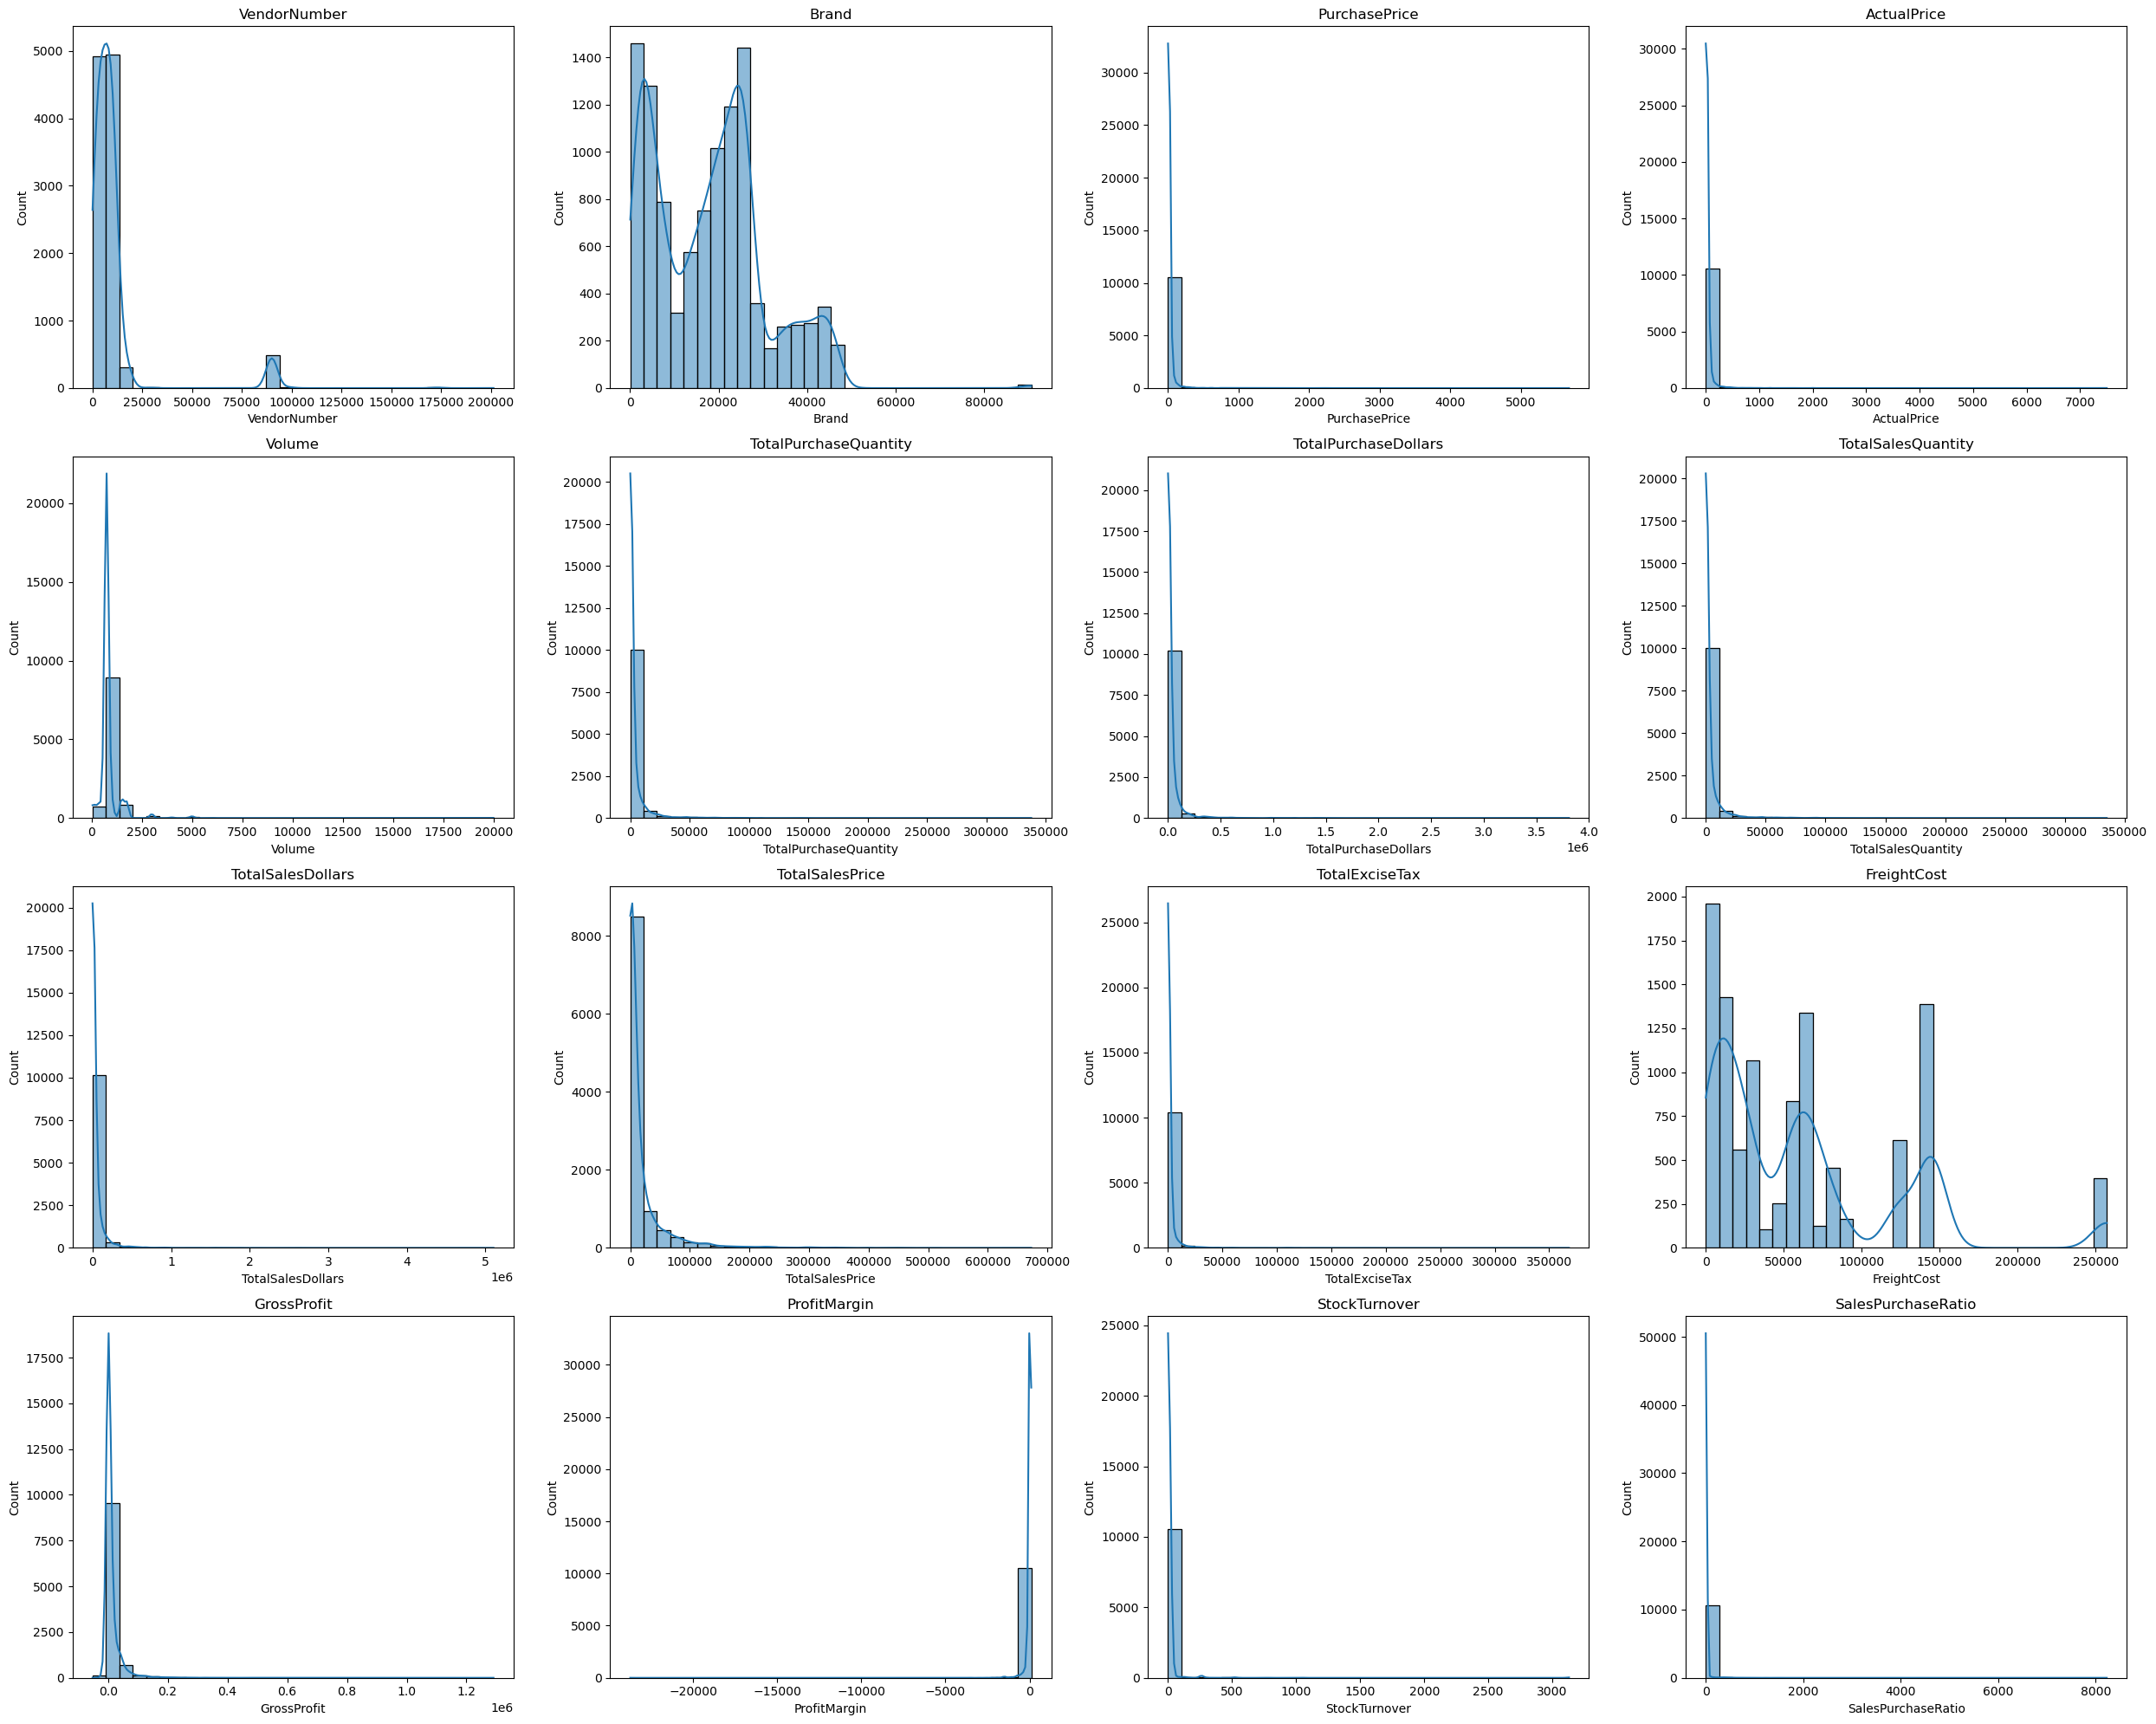

In [7]:
# Distribution Plots for Numerical Columns
numerical_cols = df.select_dtypes(include = np.number).columns

plt.figure(figsize = (25, 20))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1) # Adjust grid layout as needed 
    sns.histplot(df[col] ,kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

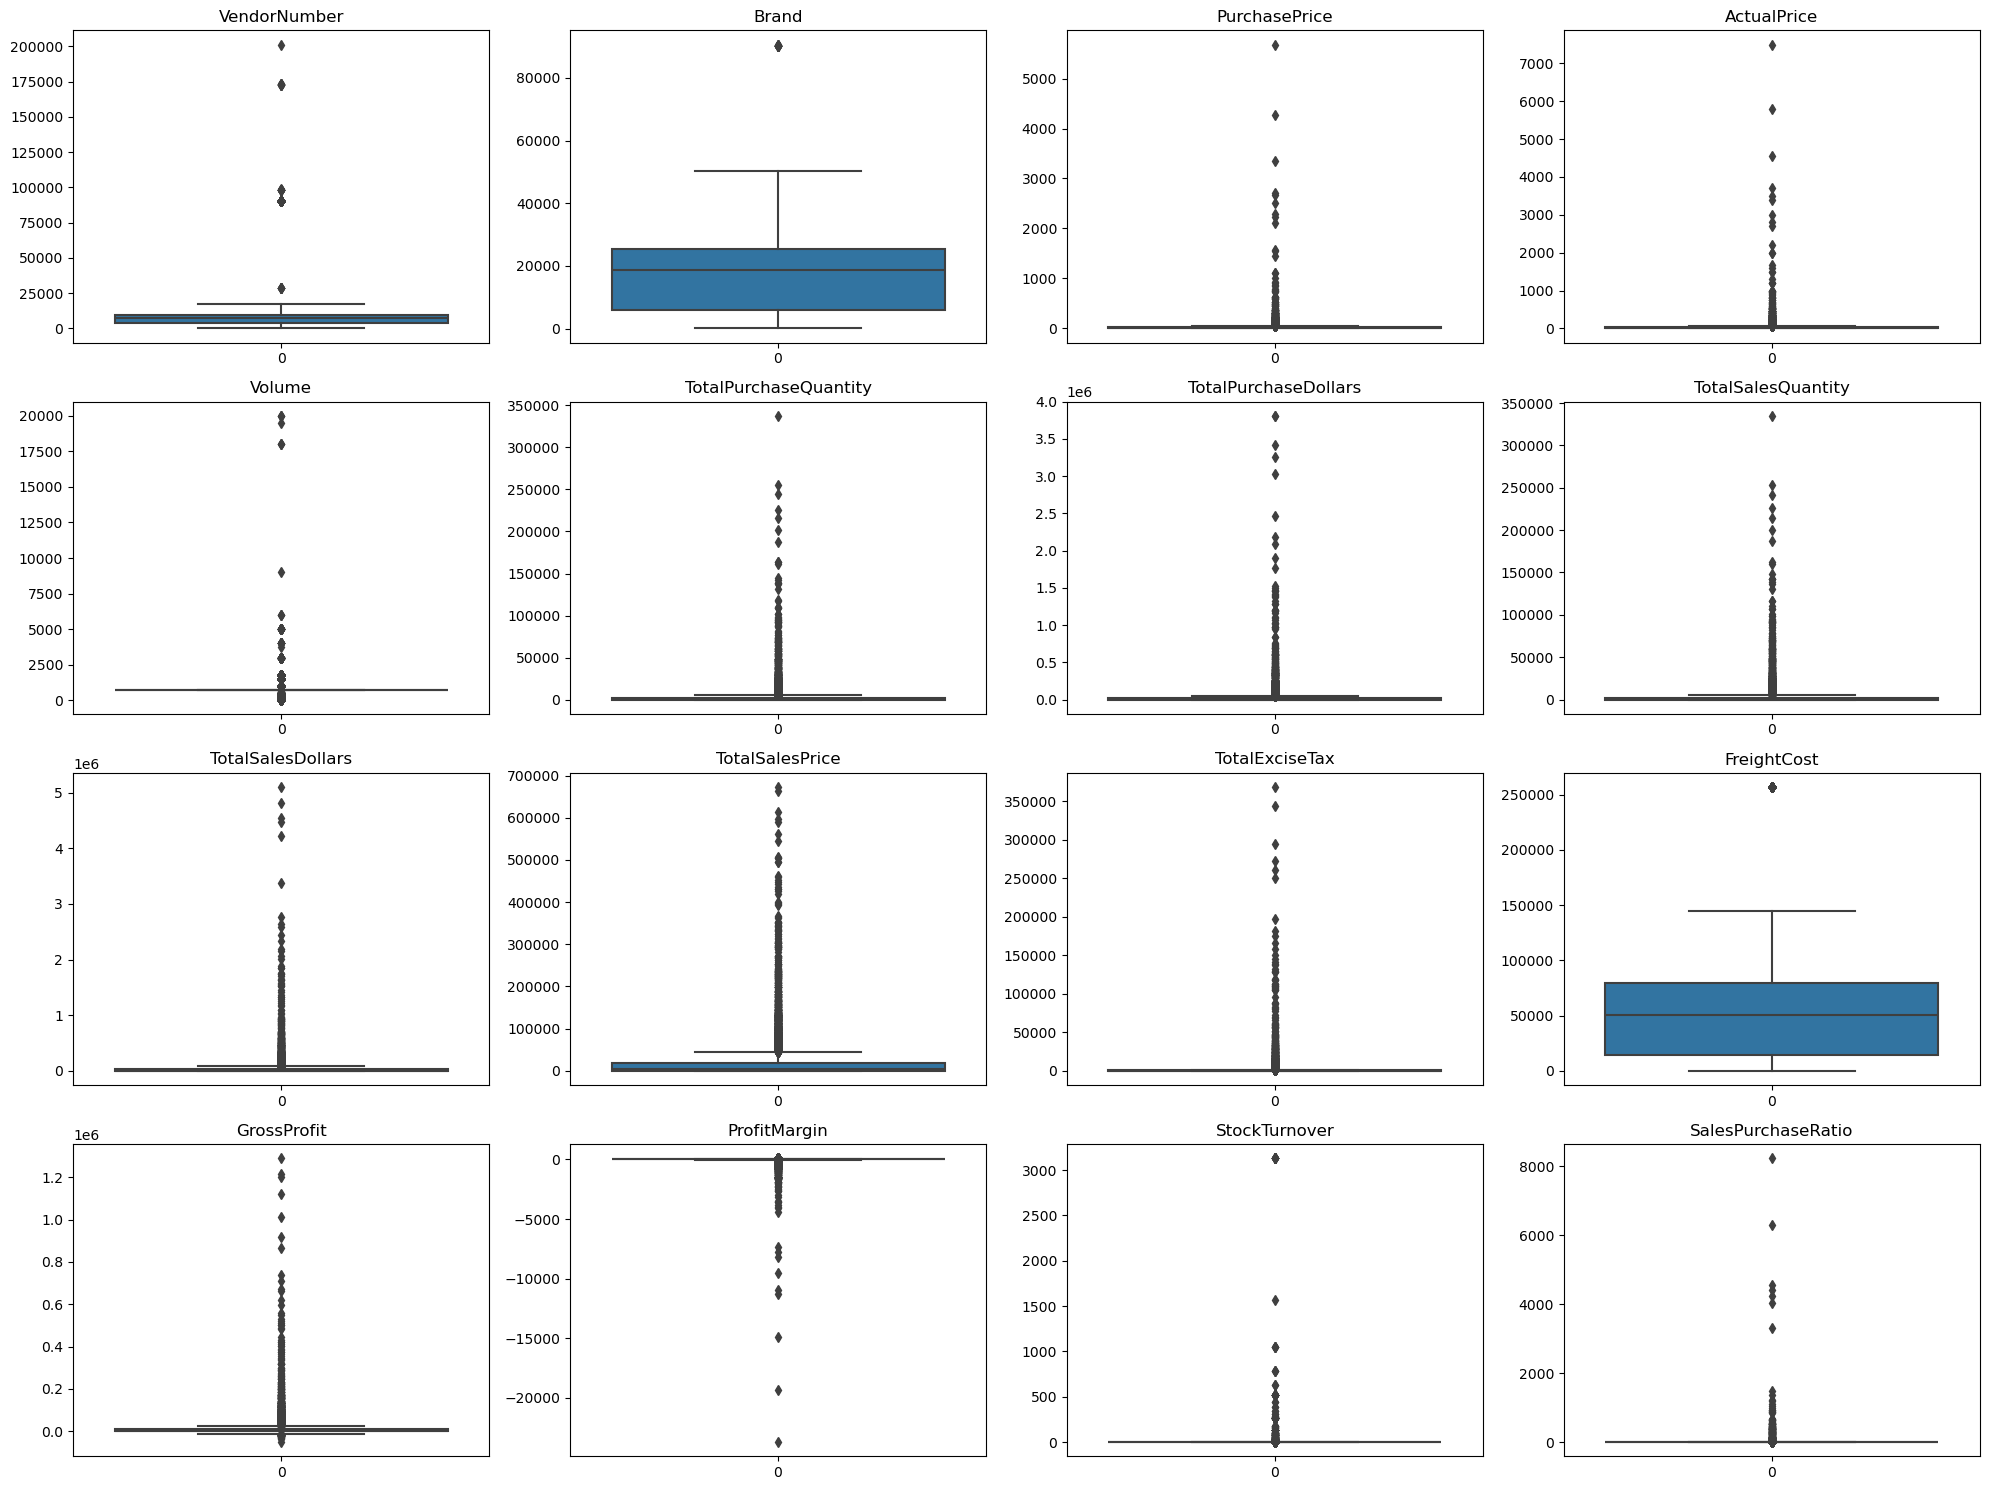

In [8]:
plt.figure(figsize = (20, 15))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1) # Adjust grid layout as needed 
    sns.boxplot(df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [9]:
df = pd.read_sql(
    '''SELECT * FROM vendor_sales_summary
    WHERE "GrossProfit" > 0
    AND "ProfitMargin" > 0
    AND "TotalSalesQuantity" > 0;''',engine)

In [10]:
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080.0,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038.0,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407.0,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682.0,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109.0,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


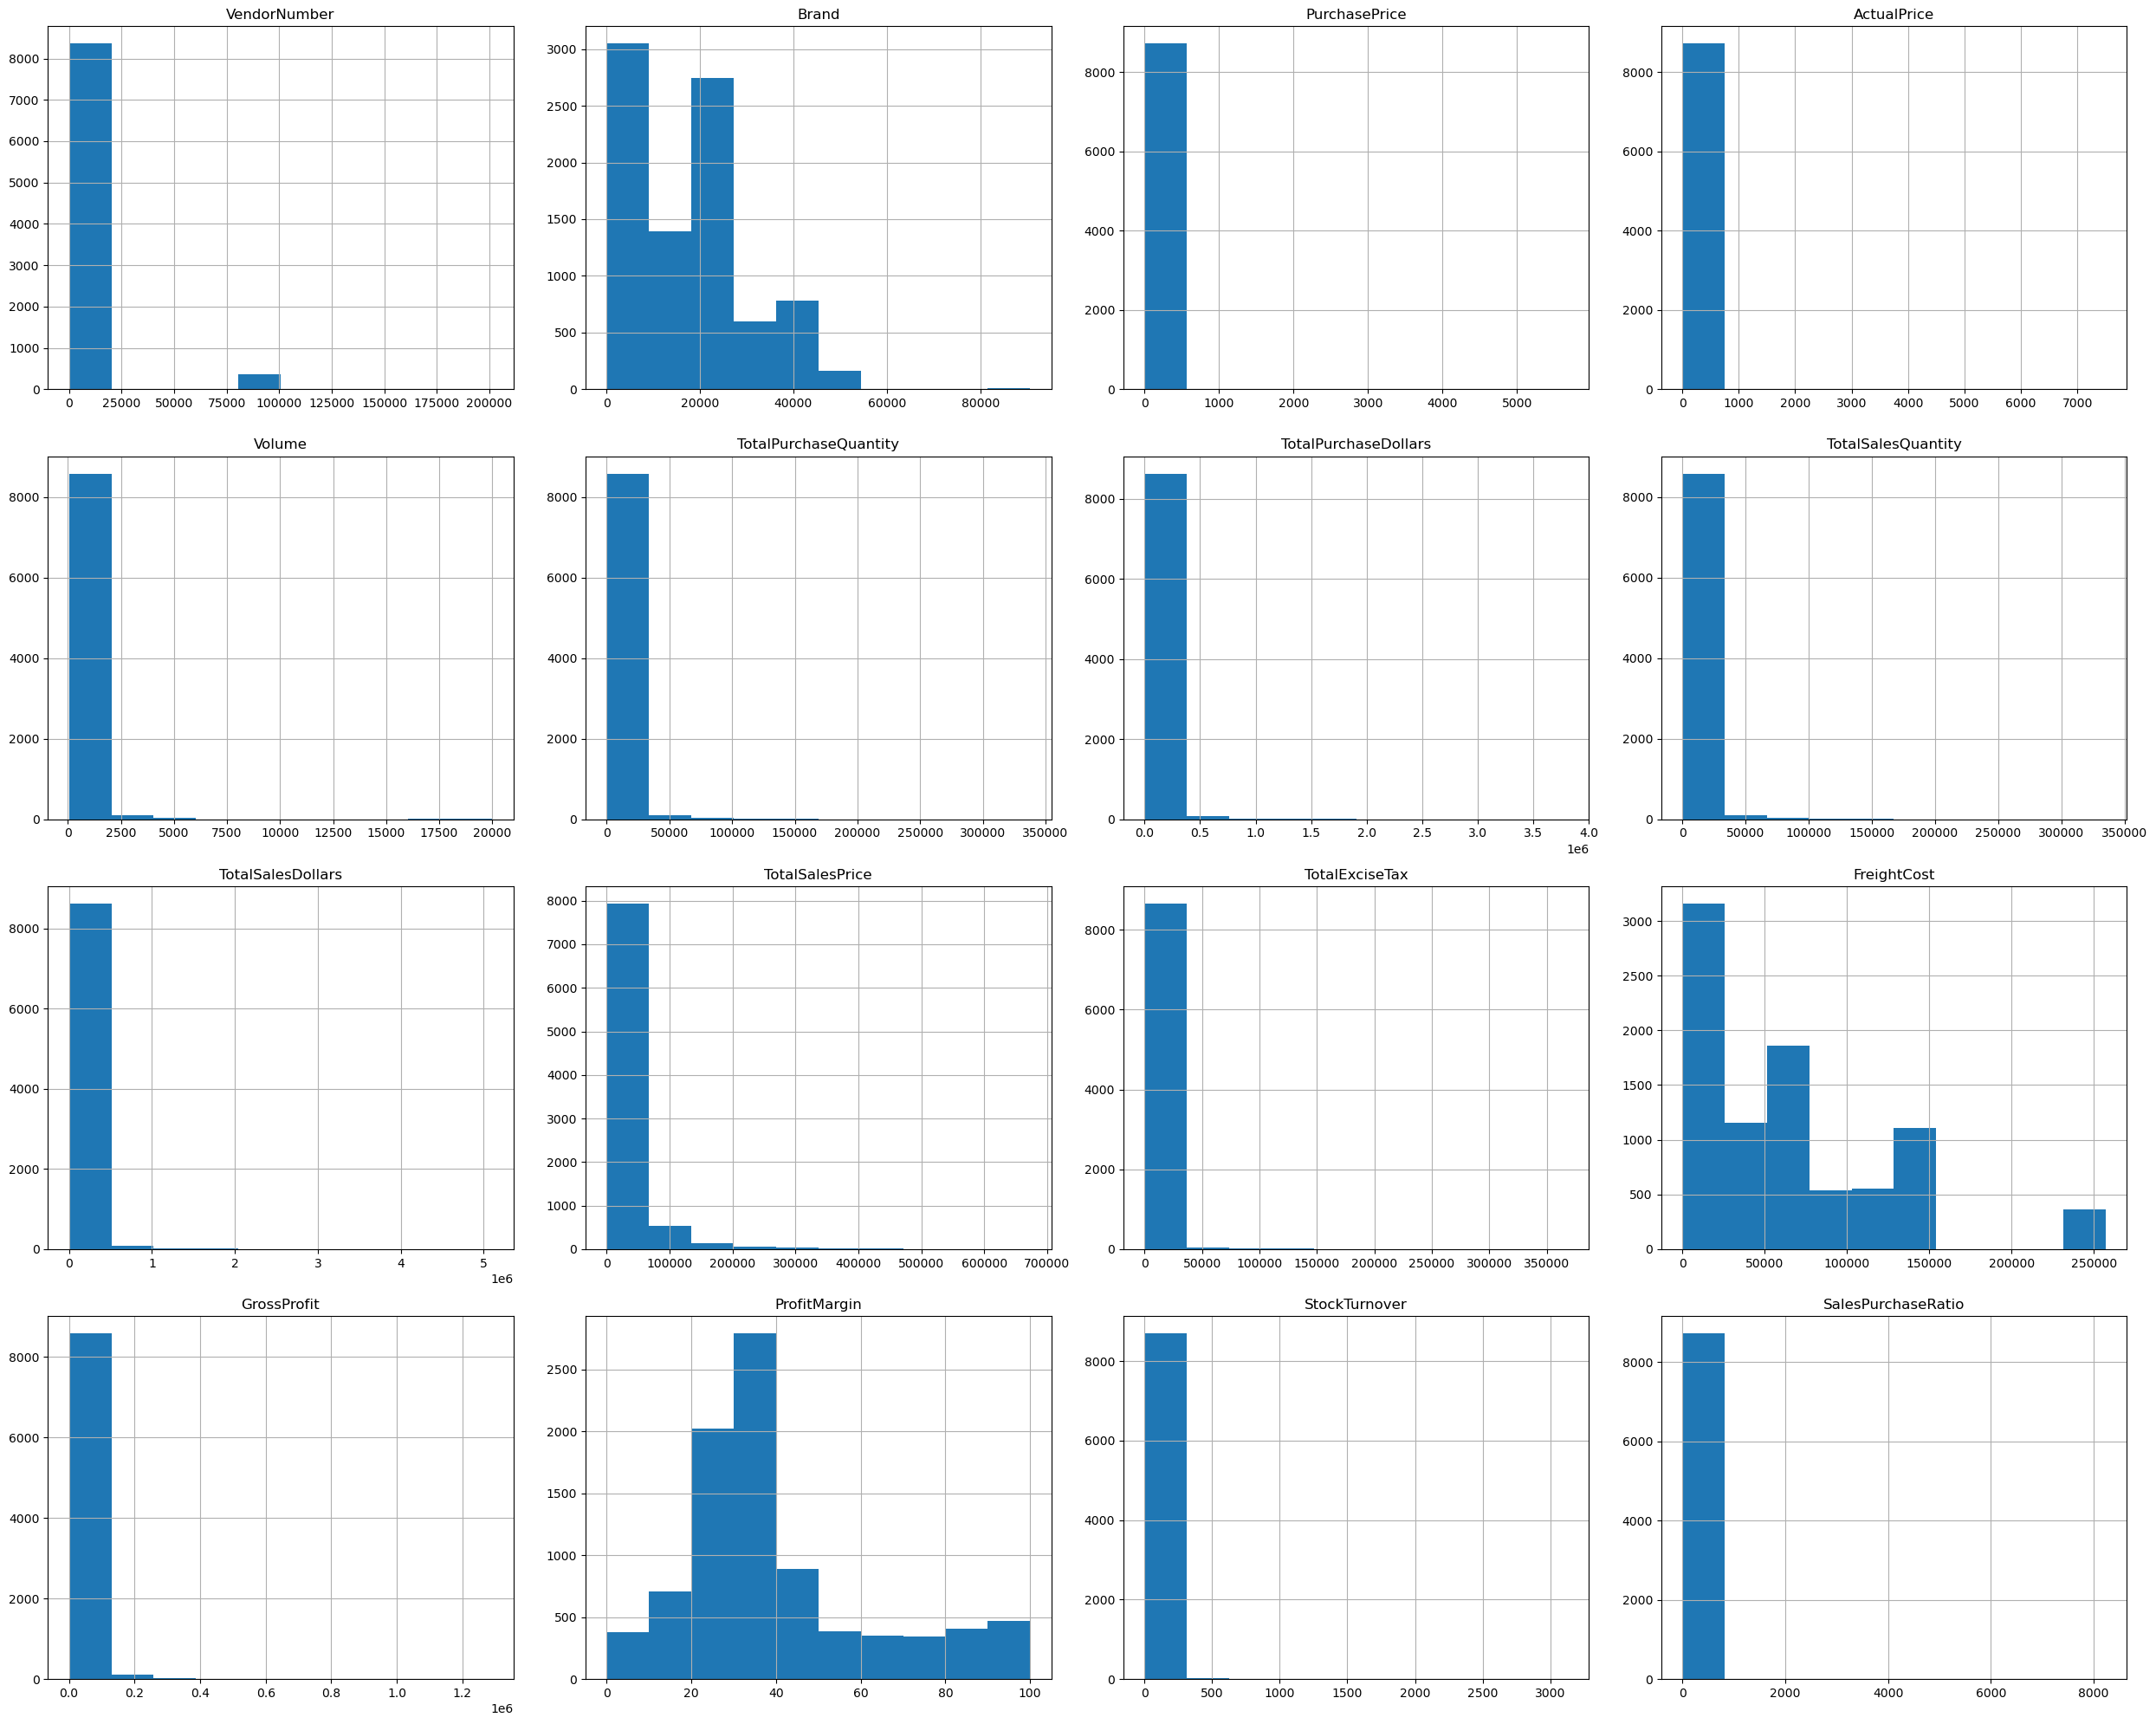

In [11]:
df.hist(figsize = (25, 20))
plt.tight_layout()
plt.show()

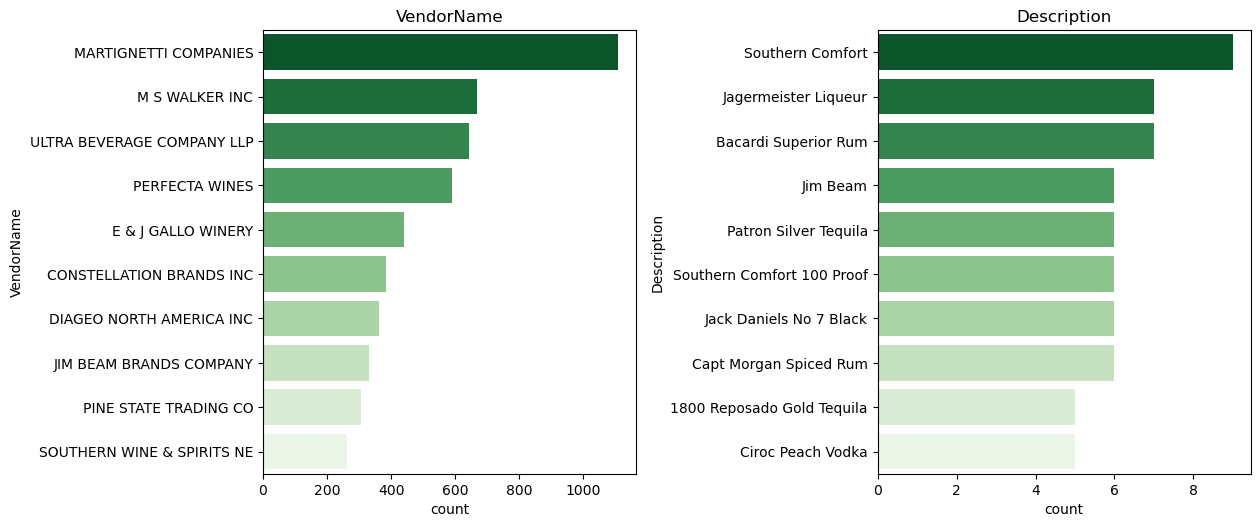

In [12]:
categorical_cols = ["VendorName", "Description"]

plt.figure(figsize = (25, 20))
for i, col in enumerate(categorical_cols):
    plt.subplot(4, 4, i+1) # Adjust grid layout as needed 
    sns.countplot(y = df[col], order=df[col].value_counts().index [:10], palette = 'Greens_r') # Top 1 categories)
    plt.title(col)
plt.tight_layout()
plt.show()

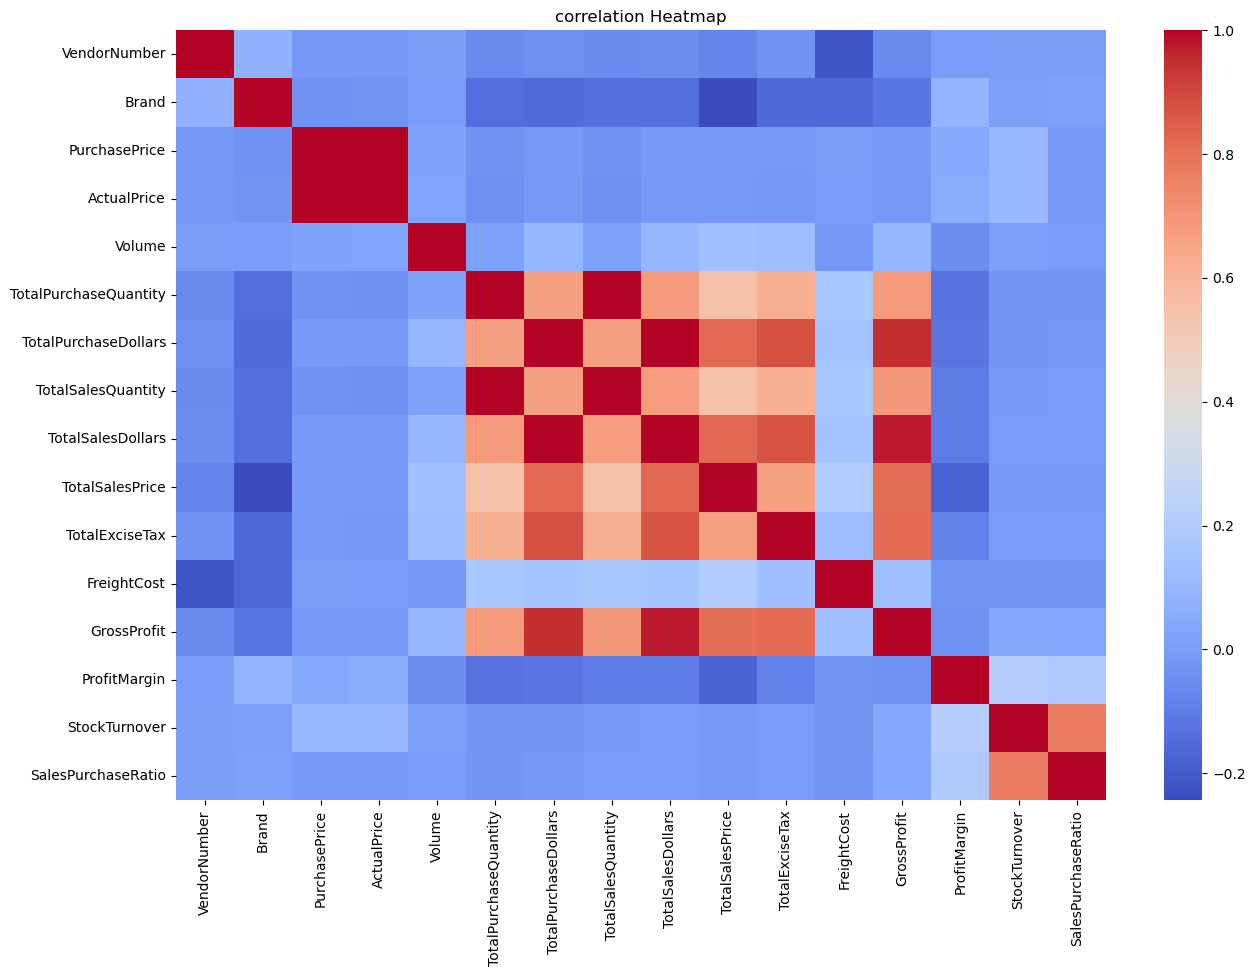

In [13]:
# Correlation Heatmap
plt.figure(figsize = (15, 10))
correlation_matrix = df [numerical_cols].corr()
sns.heatmap(correlation_matrix, cmap = "coolwarm")
plt.title("correlation Heatmap")
plt.show()

# solving reserch questions

## 1. Identify brands that needs promotional or pricing adjestment with exhibit lower sales performance but higher profit margin

In [16]:
brand_performance = df.groupby('Description').agg({
    'TotalSalesDollars': 'sum',
    'ProfitMargin': 'mean'}).reset_index()

low_sales_threshold = brand_performance['TotalSalesDollars'].quantile(0.15) #15%
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85) #85%

In [17]:
target_brands = brand_performance[
(brand_performance['TotalSalesDollars'] <= low_sales_threshold) &
(brand_performance['ProfitMargin'] >= high_margin_threshold)]

display(target_brands.sort_values('TotalSalesDollars'))

,Description,TotalSalesDollars,ProfitMargin
2112,Concannon Glen Ellen Wh Zin,15.95,83.448276
2234,Crown Royal Apple,27.86,89.806174
6375,Sauza Sprklg Wild Berry Marg,27.96,82.153076
4939,Merry Irish Cream Liqueur,35.97,73.533500
7341,Tracia Syrah,44.94,88.495772
...,...,...,...
6732,Spring 44 Gin,531.81,69.929110
5191,Nanbu Bijin Southern Beauty,535.68,76.747312
2319,Dad's Hat Rye Whiskey,538.89,81.851584
3400,Goulee Cos d'Estournel 10,558.87,69.434752


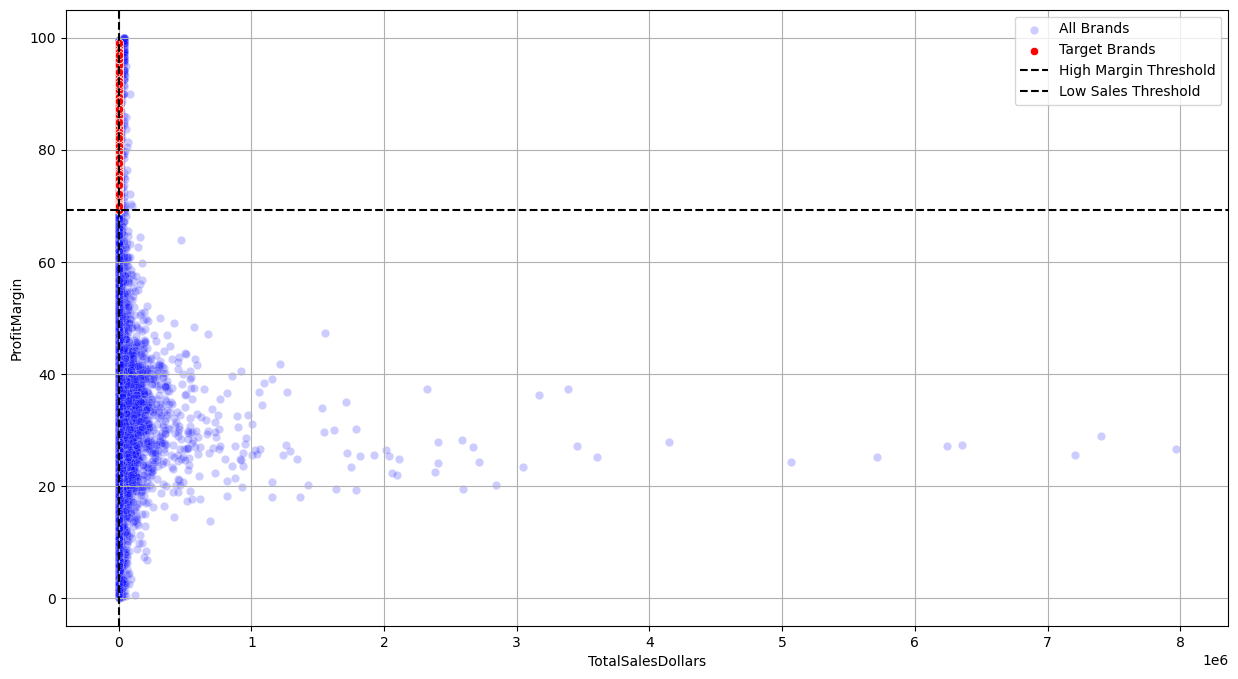

In [18]:
plt.figure(figsize=(15, 8))
sns.scatterplot(data = brand_performance, x = 'TotalSalesDollars', y='ProfitMargin',color = 'blue',label = 'All Brands', alpha = 0.2)
sns.scatterplot(data = target_brands, x = 'TotalSalesDollars', y = 'ProfitMargin', color = 'red', label = 'Target Brands')

plt.axhline(high_margin_threshold, linestyle = '--', color='black', label = 'High Margin Threshold')
plt.axvline(low_sales_threshold, linestyle = '--', color='black', label = 'Low Sales Threshold')

plt.legend()
plt.grid(True)
plt.show()

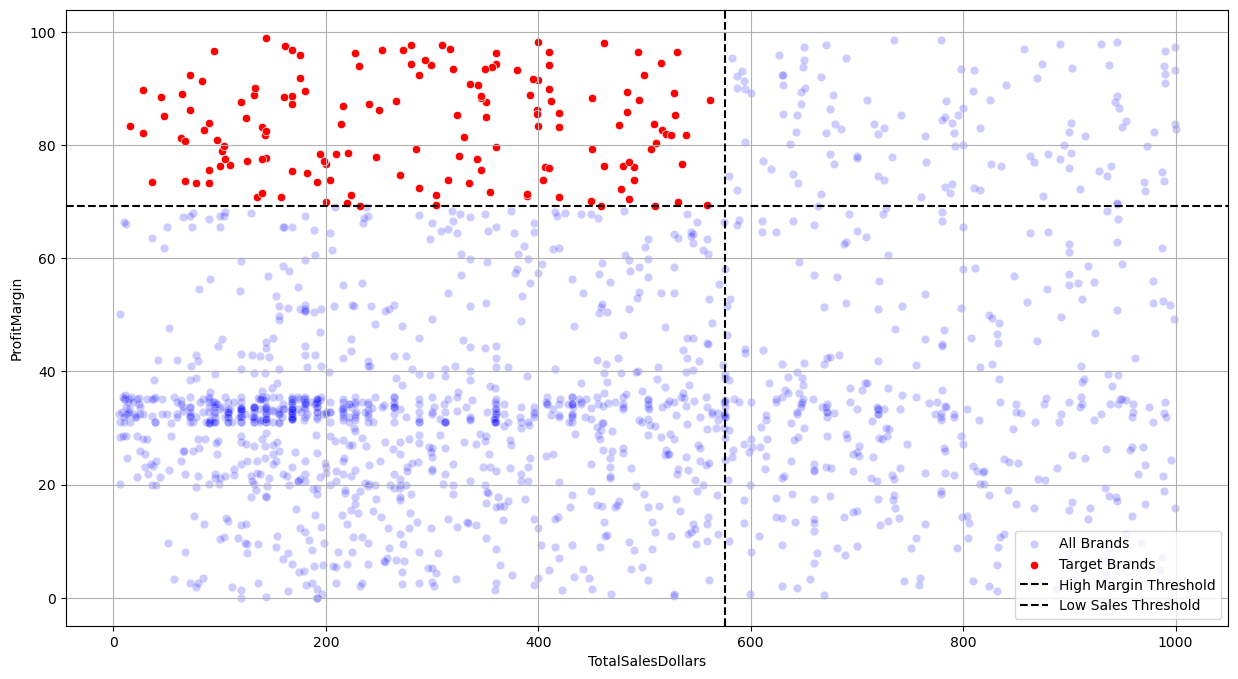

In [19]:
# for better visualization only
brand_performance = brand_performance[brand_performance['TotalSalesDollars'] < 1000]

plt.figure(figsize=(15, 8))
sns.scatterplot(data = brand_performance, x='TotalSalesDollars', y='ProfitMargin',color = 'blue',label = 'All Brands', alpha = 0.2)
sns.scatterplot(data = target_brands, x='TotalSalesDollars', y = 'ProfitMargin', color = 'red', label = 'Target Brands')

plt.axhline(high_margin_threshold, linestyle = '--', color='black', label = 'High Margin Threshold')
plt.axvline(low_sales_threshold, linestyle = '--', color='black', label = 'Low Sales Threshold')

plt.legend()
plt.grid(True)
plt.show()

## 2. which vendors and brands demonstrate the highest sales performance

,VendorName,TotalSalesDollars
0,DIAGEO NORTH AMERICA INC,6.803305e+07
1,MARTIGNETTI COMPANIES,4.040421e+07
2,PERNOD RICARD USA,3.206320e+07
3,JIM BEAM BRANDS COMPANY,3.142302e+07
4,BACARDI USA INC,2.489777e+07
5,CONSTELLATION BRANDS INC,2.439056e+07
6,E & J GALLO WINERY,1.852876e+07
7,BROWN-FORMAN CORP,1.824723e+07
8,ULTRA BEVERAGE COMPANY LLP,1.744754e+07
9,M S WALKER INC,1.539373e+07


<Axes: xlabel='TotalSalesDollars', ylabel='VendorName'>

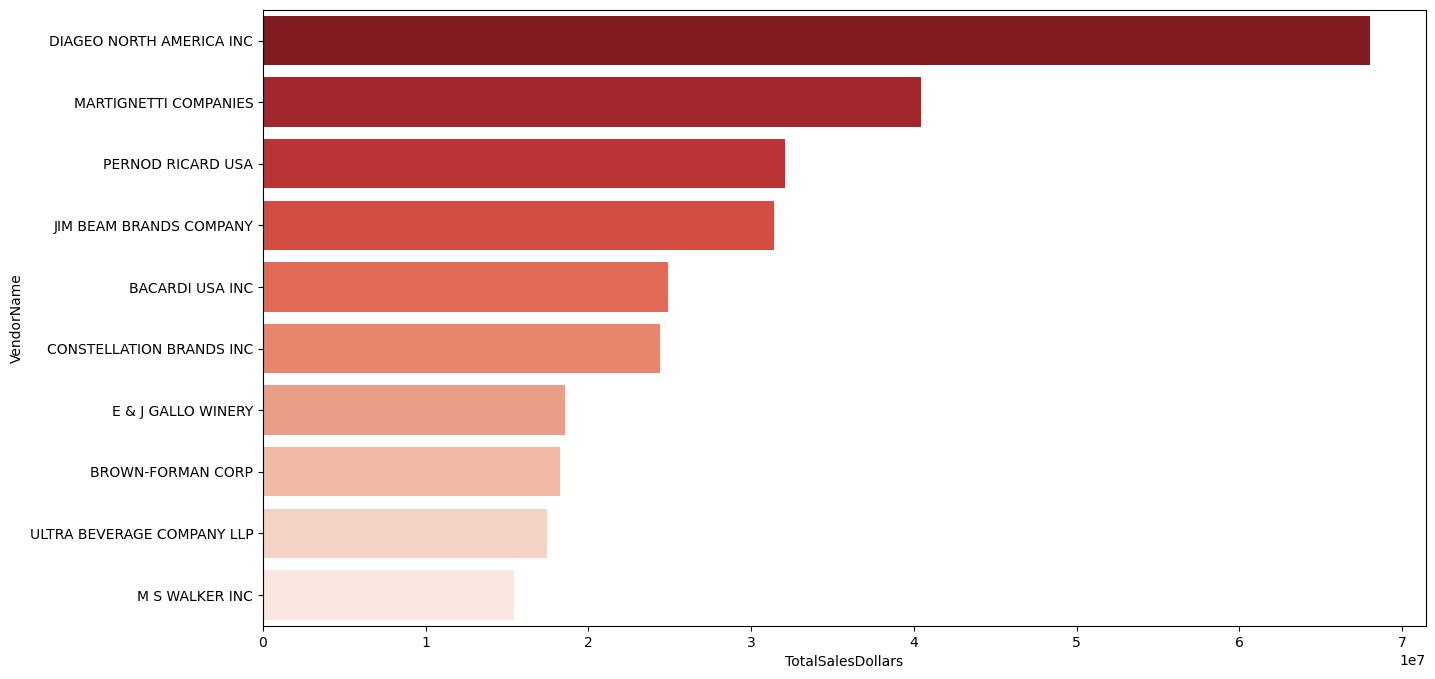

In [21]:
top_vendors = df.groupby('VendorName')['TotalSalesDollars'].sum().nlargest(10).reset_index()
display(top_vendors) 
plt.figure(figsize = (15, 8))
sns.barplot(y = 'VendorName',x = 'TotalSalesDollars', data = top_vendors, palette = 'Reds_r')

,Description,TotalSalesDollars
0,Jack Daniels No 7 Black,7964746.76
1,Tito's Handmade Vodka,7399657.58
2,Grey Goose Vodka,7209608.06
3,Capt Morgan Spiced Rum,6356320.62
4,Absolut 80 Proof,6244752.03
5,Jameson Irish Whiskey,5715759.69
6,Ketel One Vodka,5070083.56
7,Baileys Irish Cream,4150122.07
8,Kahlua,3604858.66
9,Tanqueray,3456697.90


<Axes: xlabel='TotalSalesDollars', ylabel='Description'>

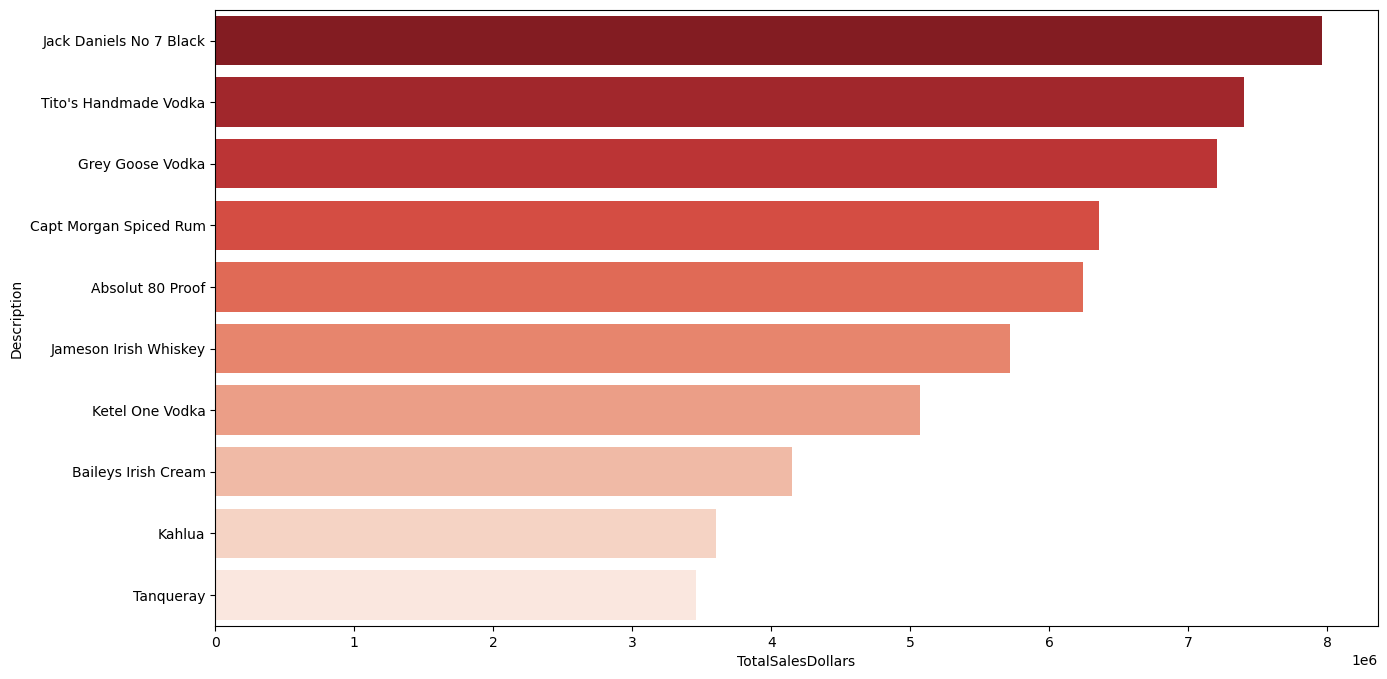

In [22]:
top_brands = df.groupby('Description')['TotalSalesDollars'].sum().nlargest(10).reset_index()
display(top_brands) 
plt.figure(figsize = (15, 8))
sns.barplot(y = 'Description',x = 'TotalSalesDollars', data = top_brands, palette = 'Reds_r')

## which vendors contribute the most to total purchase dollars

In [24]:
vendor_performance = df.groupby('VendorName').agg(
    {'TotalPurchaseDollars': 'sum',
    'TotalSalesDollars': 'sum',
    'GrossProfit': 'sum'}).sort_values('TotalPurchaseDollars', ascending = False).reset_index()

In [25]:
vendor_performance['PurchaseContribution(%)'] = (vendor_performance['TotalPurchaseDollars'] / vendor_performance['TotalPurchaseDollars'].sum()) * 100
vendor_performance['CumulativeContribution(%)'] = vendor_performance['PurchaseContribution(%)'].cumsum()
Top10VendorsByPC = vendor_performance.nlargest(10,'PurchaseContribution(%)')
display(Top10VendorsByPC)

,VendorName,TotalPurchaseDollars,TotalSalesDollars,GrossProfit,PurchaseContribution(%),CumulativeContribution(%)
0,DIAGEO NORTH AMERICA INC,50097235.60,6.803305e+07,1.793582e+07,16.285396,16.285396
1,MARTIGNETTI COMPANIES,25545349.12,4.040421e+07,1.485886e+07,8.304173,24.589569
2,PERNOD RICARD USA,23851164.17,3.206320e+07,8.212032e+06,7.753435,32.343004
3,JIM BEAM BRANDS COMPANY,23494304.32,3.142302e+07,7.928716e+06,7.637428,39.980432
4,BACARDI USA INC,17432069.96,2.489777e+07,7.465701e+06,5.666743,45.647175
5,CONSTELLATION BRANDS INC,15277916.69,2.439056e+07,9.112646e+06,4.966480,50.613655
6,BROWN-FORMAN CORP,13238939.18,1.824723e+07,5.008291e+06,4.303658,54.917313
7,E & J GALLO WINERY,12071987.90,1.852876e+07,6.456774e+06,3.924310,58.841623
8,ULTRA BEVERAGE COMPANY LLP,11277723.94,1.744754e+07,6.169812e+06,3.666114,62.507738
9,M S WALKER INC,9822050.00,1.539373e+07,5.571675e+06,3.192910,65.700648


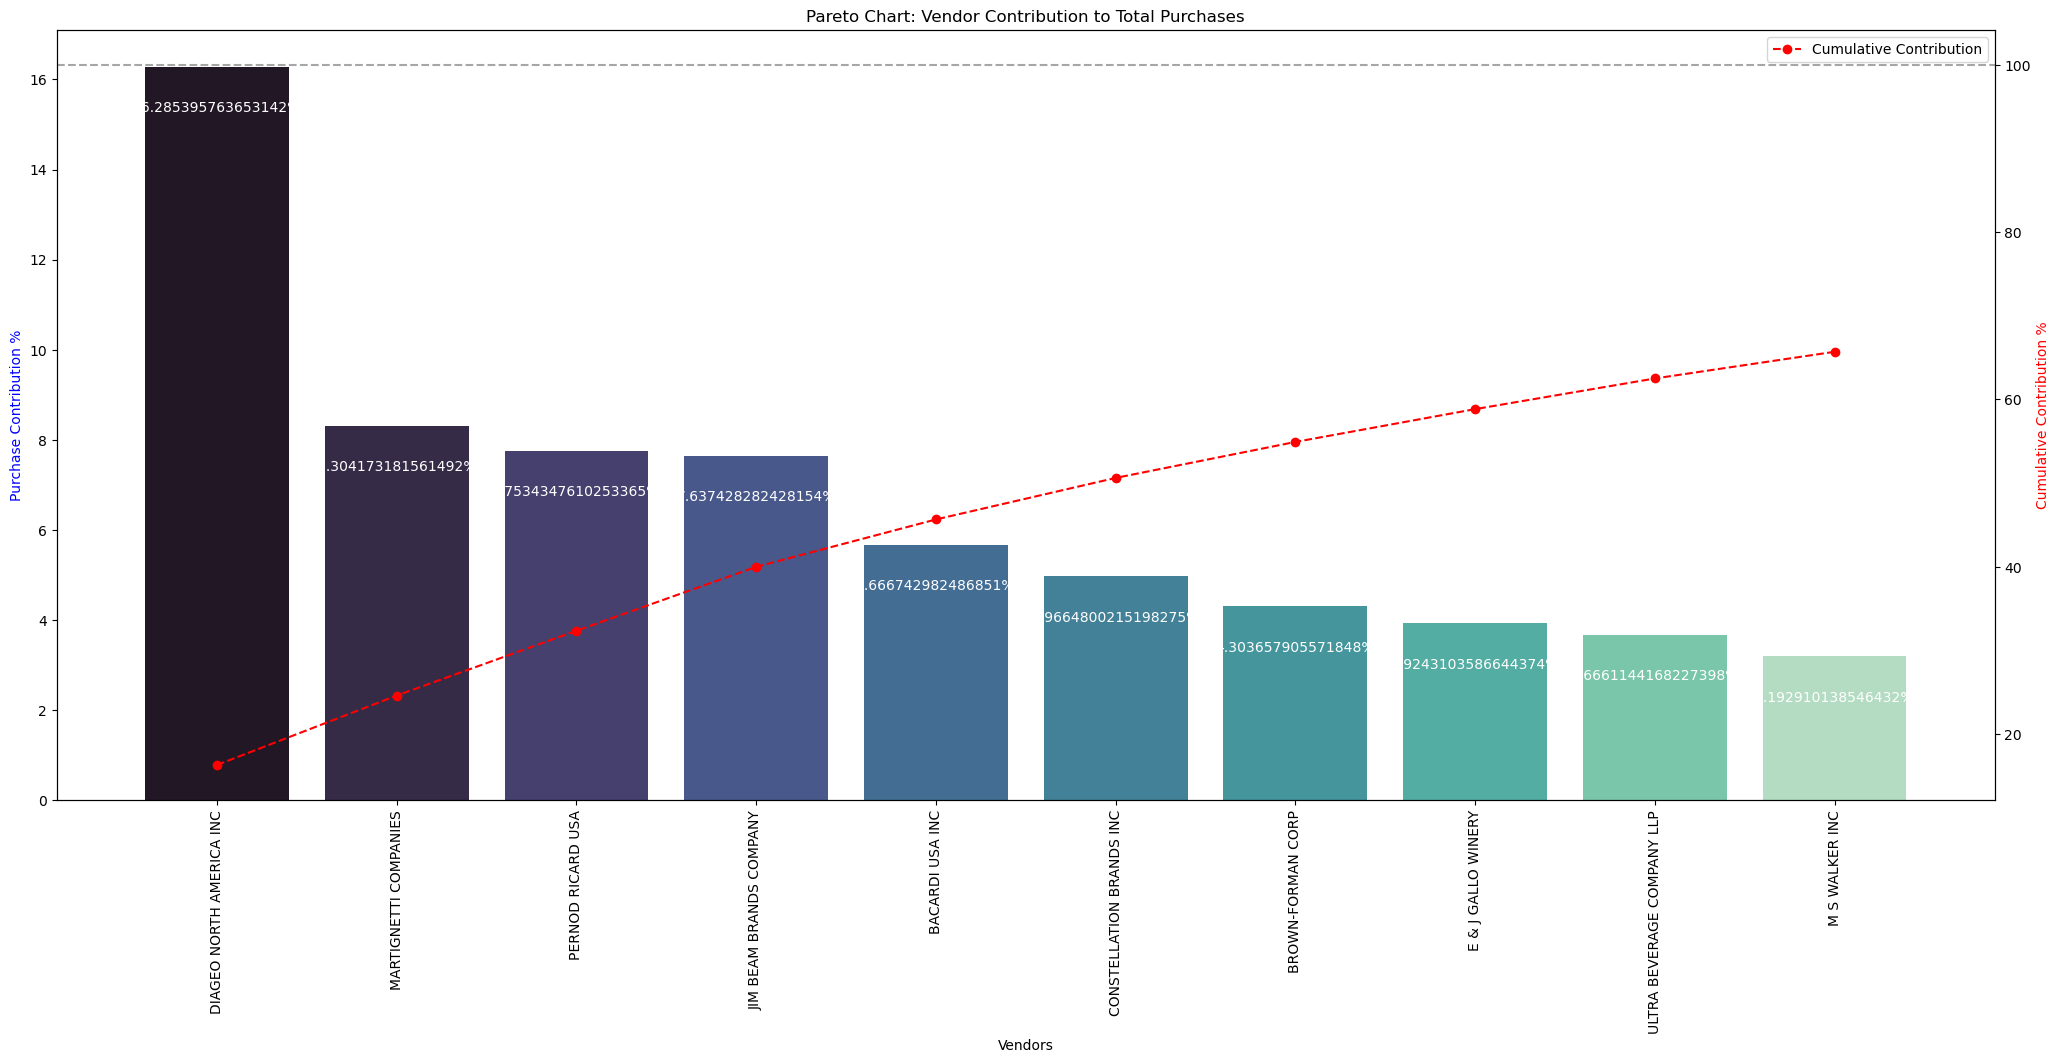

In [26]:
fig, ax1 = plt.subplots(figsize = (25, 10))

# Bar plot for Purchase Contribulion%
sns.barplot(x = 'VendorName', y = 'PurchaseContribution(%)', data = Top10VendorsByPC, palette = 'mako', ax=ax1)

for i, value in enumerate(Top10VendorsByPC['PurchaseContribution(%)']):
    ax1.text(i, value - 1, str(value)+'%', ha = 'center', fontsize = 10, color = 'white')

ax2 = ax1.twinx()
ax2.plot(Top10VendorsByPC['VendorName'], Top10VendorsByPC['CumulativeContribution(%)'], color = 'red', marker = 'o', linestyle = 'dashed', label = 'Cumulative Contribution')

ax1.set_xticklabels(Top10VendorsByPC['VendorName'], rotation = 90)
ax1.set_ylabel('Purchase Contribution %', color = 'blue')
ax2.set_ylabel('Cumulative Contribution %', color = 'red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases')

ax2.axhline(y = 100, color = 'gray', linestyle = 'dashed', alpha = 0.7)
ax2.legend(loc = 'upper right')

plt.show()


## how much of total procurement is dependent on the top vendors

In [28]:
print(f'total purchase contribution of top 10 vendors is {round(Top10VendorsByPC["PurchaseContribution(%)"].sum(),2)} %')

total purchase contribution of top 10 vendors is 65.7 %


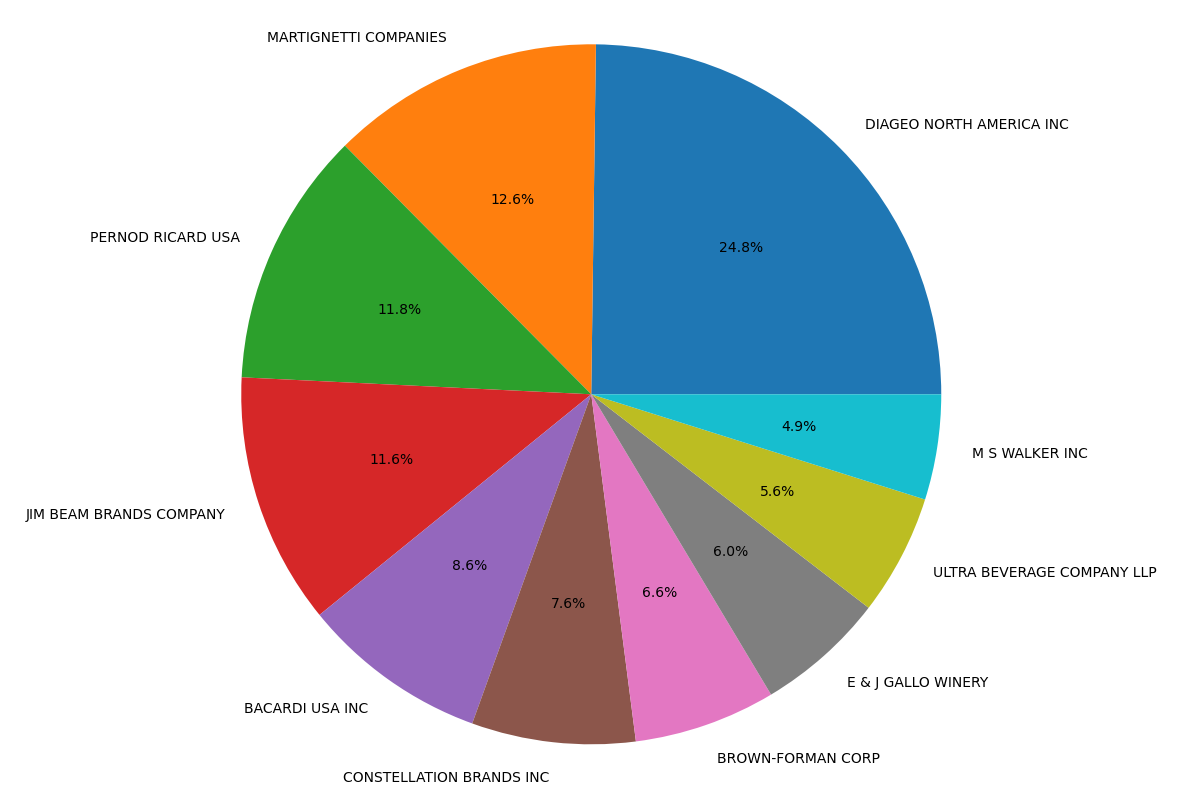

In [29]:
plt.figure(figsize = (15,10))
plt.pie(Top10VendorsByPC['PurchaseContribution(%)'], labels = Top10VendorsByPC['VendorName'], autopct = '%1.1f%%')
plt.axis('equal')
plt.show()

## does purchasing in bulk reduce the unit price, and what is the optimal purchase volume for cost saving

In [31]:
df['UnitPurchasePrice'] = df['TotalPurchaseDollars'] / df['TotalPurchaseQuantity']

In [32]:
df['OrderSize'] = pd.qcut(df['TotalPurchaseQuantity'], q = 3, labels = ['Small','Medium','Large'])

In [33]:
df.groupby(['OrderSize'])[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
Small,42.553146
Medium,15.612805
Large,10.847855


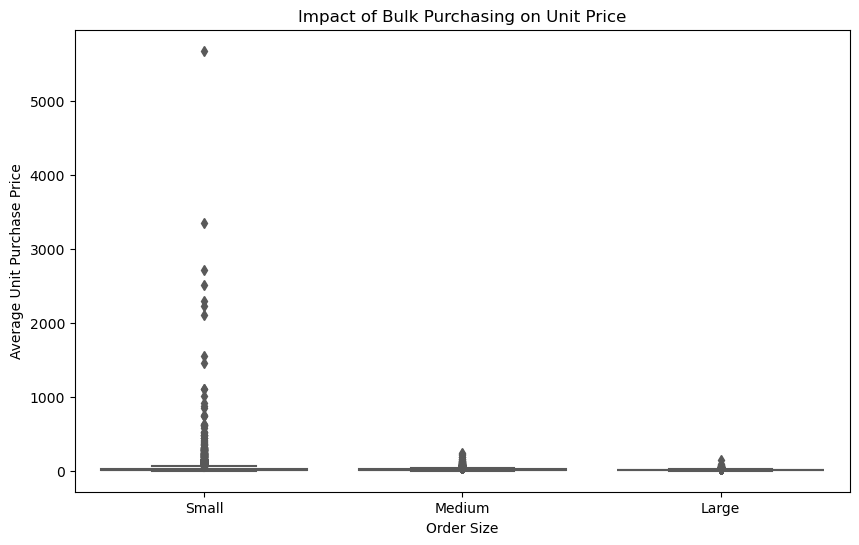

In [34]:
plt.figure(figsize=(10, 6))
sns.boxplot (data=df, x="OrderSize", y="UnitPurchasePrice", palette="Set2")
plt.title("lmpact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")
plt.show()

## which vendors have low inventory turnover, indicating excess stock and slow - moving products ?

In [36]:
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover', ascending = True).head(10)

,StockTurnover
VendorName,
ALISA CARR BEVERAGES,0.615385
HIGHLAND WINE MERCHANTS LLC,0.708333
PARK STREET IMPORTS LLC,0.751306
Circa Wines,0.755676
Dunn Wine Brokers,0.766022
CENTEUR IMPORTS LLC,0.773953
SMOKY QUARTZ DISTILLERY LLC,0.783835
TAMWORTH DISTILLING,0.797078
THE IMPORTED GRAPE LLC,0.807569


## how much capital is locked in unsold inventory per vendor, and which vendor contribute most to it ?

In [38]:
df ["UnsoldInventoryValue"] = (df["TotalPurchaseQuantity"] - df["TotalSalesQuantity"]) * df["PurchasePrice"]
print('Total Unsold Capital:', df["UnsoldInventoryValue"].sum())

Total Unsold Capital: -42706469.01103766


In [39]:
# Aggregate Capital Locked per Vendor
inventory_value_per_vendor = df.groupby("VendorName")["UnsoldInventoryValue"].sum().reset_index()

# Sort Vendors with the Highest Locked Capital
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(by = 'UnsoldInventoryValue', ascending = False)
inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
26,DIAGEO NORTH AMERICA INC,692675.223483
47,JIM BEAM BRANDS COMPANY,554665.630000
70,PERNOD RICARD USA,470625.610000
118,WILLIAM GRANT & SONS INC,401960.830000
81,SAZERAC CO INC,198436.410000
31,E & J GALLO WINERY,187541.573557
12,BROWN-FORMAN CORP,177733.740000
79,REMY COINTREAU USA INC,118598.150000
56,MAJESTIC FINE WINES,114457.320000
63,MOET HENNESSY USA INC,105839.298438


## what is 95% confidence intervals for profit margins of top - performing and low _performing vendors

In [41]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshotd = df["TotalSalesDollars"].quantile(0.25)

In [42]:
top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= top_threshold]["ProfitMargin"].dropna()

In [43]:
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data)) # Standard error
    t_critical = t.ppf((1 + confidence) / 2, df=len(data) -1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

Top Vendors 95% CI: (35.44, 37.12), Mean: 36.28
Low Vendors 95% CI: (42.02, 43.21), Mean: 42.62


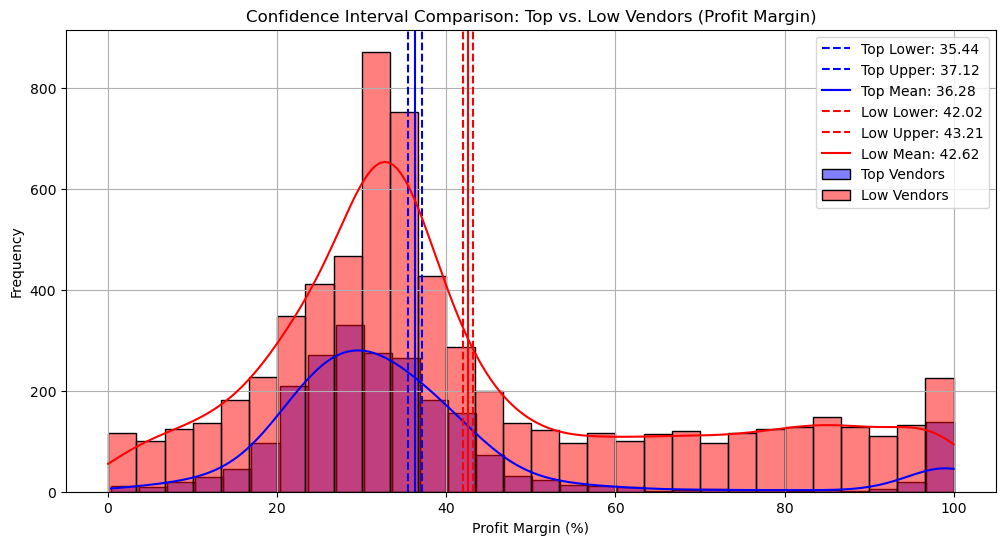

In [44]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower :.2f}, {top_upper :.2f}), Mean: {top_mean :.2f}")
print(f"Low Vendors 95% CI: ({low_lower :.2f}, {low_upper :.2f}), Mean: {low_mean :.2f}")

plt.figure(figsize=(12,6))

# Top Vendors Plot
sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower :.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper :.2f}")
plt.axvline(top_mean, color="blue", linestyle="-", label=f"Top Mean: {top_mean :.2f}")

# Low Vendors Plot
sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")
plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower :.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper :.2f}")
plt.axvline(low_mean, color="red", linestyle="-", label=f"Low Mean: {low_mean :.2f}")

# Finalize Plot
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()